## Resumo e Estrutura do Notebook

Este notebook organiza a análise exploratória do conjunto de dados `houses.csv` seguindo as recomendações do README:

- `## Etapa 1 – Estatísticas Univariadas`: descrições, distribuições e tratamento de valores ausentes
- `## Etapa 2 – Visualizações e Correlações`: gráficos, heatmaps e relacionamentos com `SalePrice`
- `## Etapa 3 – Preparação para Modelagem`: transformações e features selecionadas

Cada célula de código começa com um comentário curto indicando seu propósito e funções reutilizáveis são definidas quando apropriado. Use o índice das células para navegar (Cell 1 = primeira célula).

1) Calcular estatísticas descritivas para variáveis numéricas, como média, mediana, desvio padrão e assimetria.
- Como apresentar essas estatísticas para tantas variáveis?
- Filtrar variáveis mais relevantes?
2) Variáveis categóricas: tabelas de frequência 

3) Variáveis ordinais: mediana + moda + gráfico de barras; boxplots em relação a ``SalePrice`` ou outras variáveis numéricas; Para relacionar variáveis ordinais com ordinais (ou categóricas): heatmap contando a frequência em cada interseção
4) Mais gráficos de dispersão p/ explorar relações entre ``SalePrice`` e variáveis contínuas

## Etapa 1 – Estatísticas Univariadas

Nesta etapa calculamos estatísticas descritivas, investigamos valores ausentes e aplicamos imputações simples onde necessário. Cada célula de código inicia com um comentário objetivo conforme o padrão do README.

Aqui, organizamos as variáveis em listas para cada tipo de variável. 
Note que "SalePrice" não foi incluído na lista de variáveis numéricas embora seja desse tipo, já que é a variável de interesse final.

`Neighborhood`: Locais físicos dentro dos limites da cidade de Ames

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	VeenkerNume
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Ordinal columns: {len(ordinal_cols)}")
print(f"Total columns: {len(numerical_cols) + len(categorical_cols) + len(ordinal_cols)}")

In [ ]:
# Objetivo: carregar o dataset e definir uma função reutilizável de carregamento
import pandas as pd

def load_data(path='houses.csv'):
    """Carrega o CSV e retorna um DataFrame."""
    df = pd.read_csv(path, keep_default_na=False, na_values=['NA',''])
    return df

houses = load_data()
houses.head()

# Relatório rápido de saúde do dataset
print('Shape:', houses.shape)
print('Missing per column:\n', houses.isna().sum().sort_values(ascending=False).head(20))

In [7]:
stats_df = houses[numerical_cols].describe().T

print(stats_df)

                count          mean          std     min      25%     50%  \
LotFrontage    1201.0     70.049958    24.284752    21.0    59.00    69.0   
LotArea        1460.0  10516.828082  9981.264932  1300.0  7553.50  9478.5   
MasVnrArea     1452.0    103.685262   181.066207     0.0     0.00     0.0   
BsmtFinSF1     1460.0    443.639726   456.098091     0.0     0.00   383.5   
BsmtFinSF2     1460.0     46.549315   161.319273     0.0     0.00     0.0   
BsmtUnfSF      1460.0    567.240411   441.866955     0.0   223.00   477.5   
TotalBsmtSF    1460.0   1057.429452   438.705324     0.0   795.75   991.5   
1stFlrSF       1460.0   1162.626712   386.587738   334.0   882.00  1087.0   
2ndFlrSF       1460.0    346.992466   436.528436     0.0     0.00     0.0   
LowQualFinSF   1460.0      5.844521    48.623081     0.0     0.00     0.0   
GrLivArea      1460.0   1515.463699   525.480383   334.0  1129.50  1464.0   
BsmtFullBath   1460.0      0.425342     0.518911     0.0     0.00     0.0   

Depending on the description of the variable, missing values may have a specific meaning:

- ``PoolQC``: No pool 
- ``MiscFeature``: No additional feature
- ``Alley``: No access
- ``Fence``: No fence
- ``FireplaceQu``: No fireplace
- ``LotFrontage``: MISSING VALUE!!
- ``GarageFinish``, ``GarageQual``, ``GarageYrBlt``, ``GarageType``, ``GarageCond`` : No garage
- ``BsmtExposure``, ``BsmtFinType2``, ``BsmtCond``, ``BsmtFinType1``, ``BsmtQual``: No basement
- ``MasVnrArea``: MISSING VALUE!!
- ``MasVnrType``: MISSING VALUE!!
- ``Electrical``: MISSING VALUE!!

For the variables that ``NA`` has a meaning, we can substitute ``NA`` with ``None``, so that ``NA`` stay reserved for actual missing values.


For the variables that ``NA`` simply means a missing value, we can substitue ``NA`` with the median value. Although it may not be the most sofisticate way to impute values, it is more immune to extreme values than the mean value.

In [165]:
# Identificando variáveis numéricas, categóricas e ordinais (Anos movidos para numéricas)
numerical_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 
    'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'FullBath', 'HalfBath',
    'YearBuilt', 'YearRemodAdd', 'YrSold'
]

categorical_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 
    'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'MiscFeature', 
    'SaleType', 'SaleCondition'
]

ordinal_cols = [
    'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 
    'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'PoolQC', 'Fence', 'MoSold'
]

# numero total de variáveis numéricas, categóricas e ordinais
print(f"Total lines: {houses.shape[0]}")
print(f"Total columns: {len(numerical_cols) + len(categorical_cols) + len(ordinal_cols)}")

Total lines: 1460
Numerical columns: 32
Categorical columns: 26
Ordinal columns: 21
Total columns: 79


In [167]:
# Objetivo: Estatísticasce assimetria da variável alvo SalePrice
print("-Est. Desc.")
print(houses['SalePrice'].describe())

print("\n-Assimetria (Skewness)")
print(f"Coeficiente de Assimetria: {houses['SalePrice'].skew():.6f}")

-Est. Desc.
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

-Assimetria (Skewness)
Coeficiente de Assimetria: 1.882876


## Etapa 2 – Visualizações e Correlações

Nesta seção geramos visualizações para explorar relacionamentos entre variáveis e com `SalePrice` (heatmaps, boxplots e distribuições).

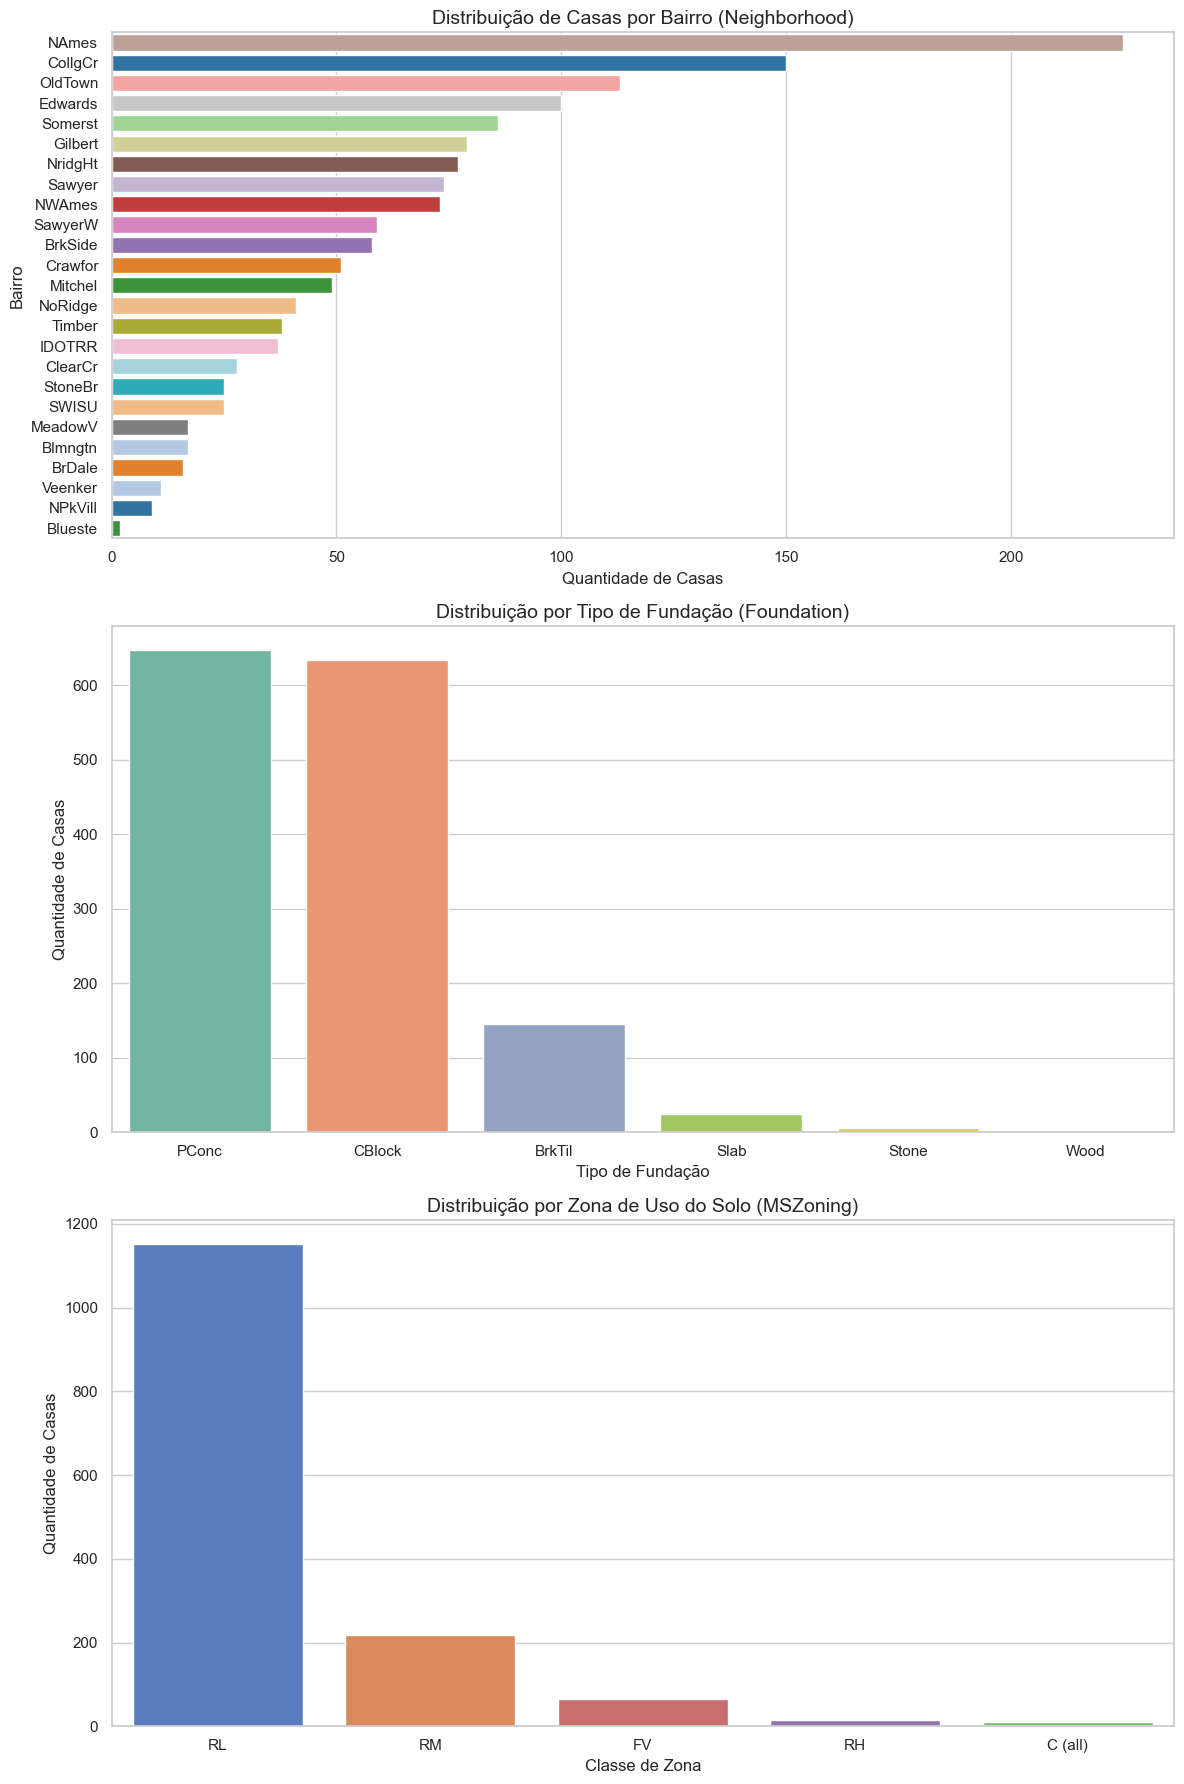

In [ ]:
# Objetivo: Plotar a frequência das vriáveis categóricas corrigindo paletas e avisos do Seaborn
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Neighborhood (Usando 'tab20' para cobrir a grande variedade de bairros)
sns.countplot(
    y=houses['Neighborhood'], 
    order=houses['Neighborhood'].value_counts().index, 
    ax=axes[0], 
    hue=houses['Neighborhood'], 
    legend=False, 
    palette='tab20'
)
axes[0].set_title('Distribuição de Casas por Bairro (Neighborhood)', fontsize=14)
axes[0].set_xlabel('Quantidade de Casas')
axes[0].set_ylabel('Bairro')

# 2. Foundation (Substituído o erro por 'Set2')
sns.countplot(
    x=houses['Foundation'], 
    order=houses['Foundation'].value_counts().index, 
    ax=axes[1], 
    hue=houses['Foundation'], 
    legend=False, 
    palette='Set2'
)
axes[1].set_title('Distribuição por Tipo de Fundação (Foundation)', fontsize=14)
axes[1].set_xlabel('Tipo de Fundação')
axes[1].set_ylabel('Quantidade de Casas')

# 3. MSZoning (Ajustado para 'muted')
sns.countplot(
    x=houses['MSZoning'], 
    order=houses['MSZoning'].value_counts().index, 
    ax=axes[2], 
    hue=houses['MSZoning'], 
    legend=False, 
    palette='muted'
)
axes[2].set_title('Distribuição por Zona de Uso do Solo (MSZoning)', fontsize=14)
axes[2].set_xlabel('Classe de Zona')
axes[2].set_ylabel('Quantidade de Casas')

plt.tight_layout()
plt.show()ar a varas variáveis numéricas em que ``NA`` significa valores ausentes (``LotFrontage`` e ``MasVnrArea``), substituímos pelo valor da mediana da variável. Já para as variáveis categóricas (``MasVnrType`` e ``Electrical``), usamos o valor da moda.

Coeficiente de Spearman:

The Spearman correlation coefficient is defined as the Pearson correlation coefficient between the rank variables.
Ranking is a data transformation in which numerical or ordinal data are replaced by their rank when the data are sorted.

C:\Users\pedro\AppData\Local\Temp\ipykernel_29000\651630342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')


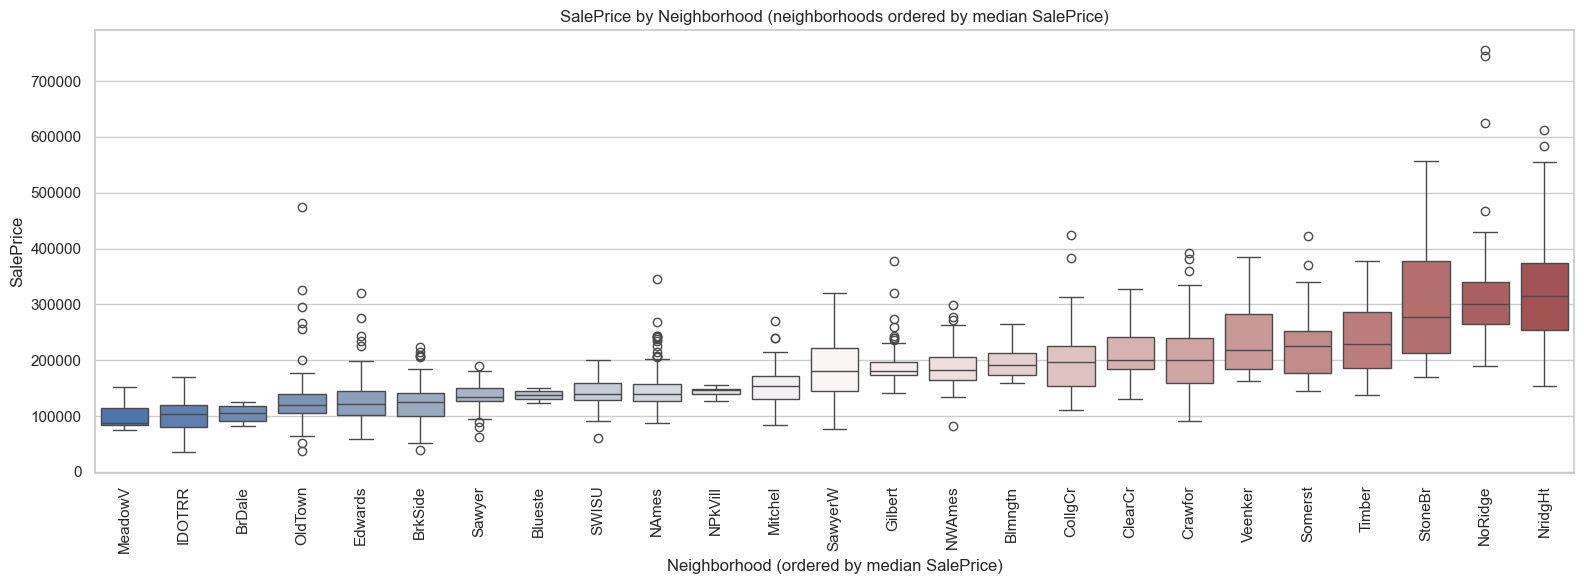

In [173]:
# Boxplot of SalePrice by Neighborhood ordered by median SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

# compute neighborhood medians and order neighborhoods from smallest to largest median
neigh_medians = houses.groupby('Neighborhood')['SalePrice'].median().sort_values()
order = neigh_medians.index

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood (neighborhoods ordered by median SalePrice)')
plt.xlabel('Neighborhood (ordered by median SalePrice)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [174]:
# 1) Check missing values and basic stats for GrLivArea
missing_grliv = houses['GrLivArea'].isna().sum()
print(f"Missing values in GrLivArea: {missing_grliv}")

# Show summary statistics to get a sense of distribution and outliers
houses['GrLivArea'].describe()


Missing values in GrLivArea: 0


count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

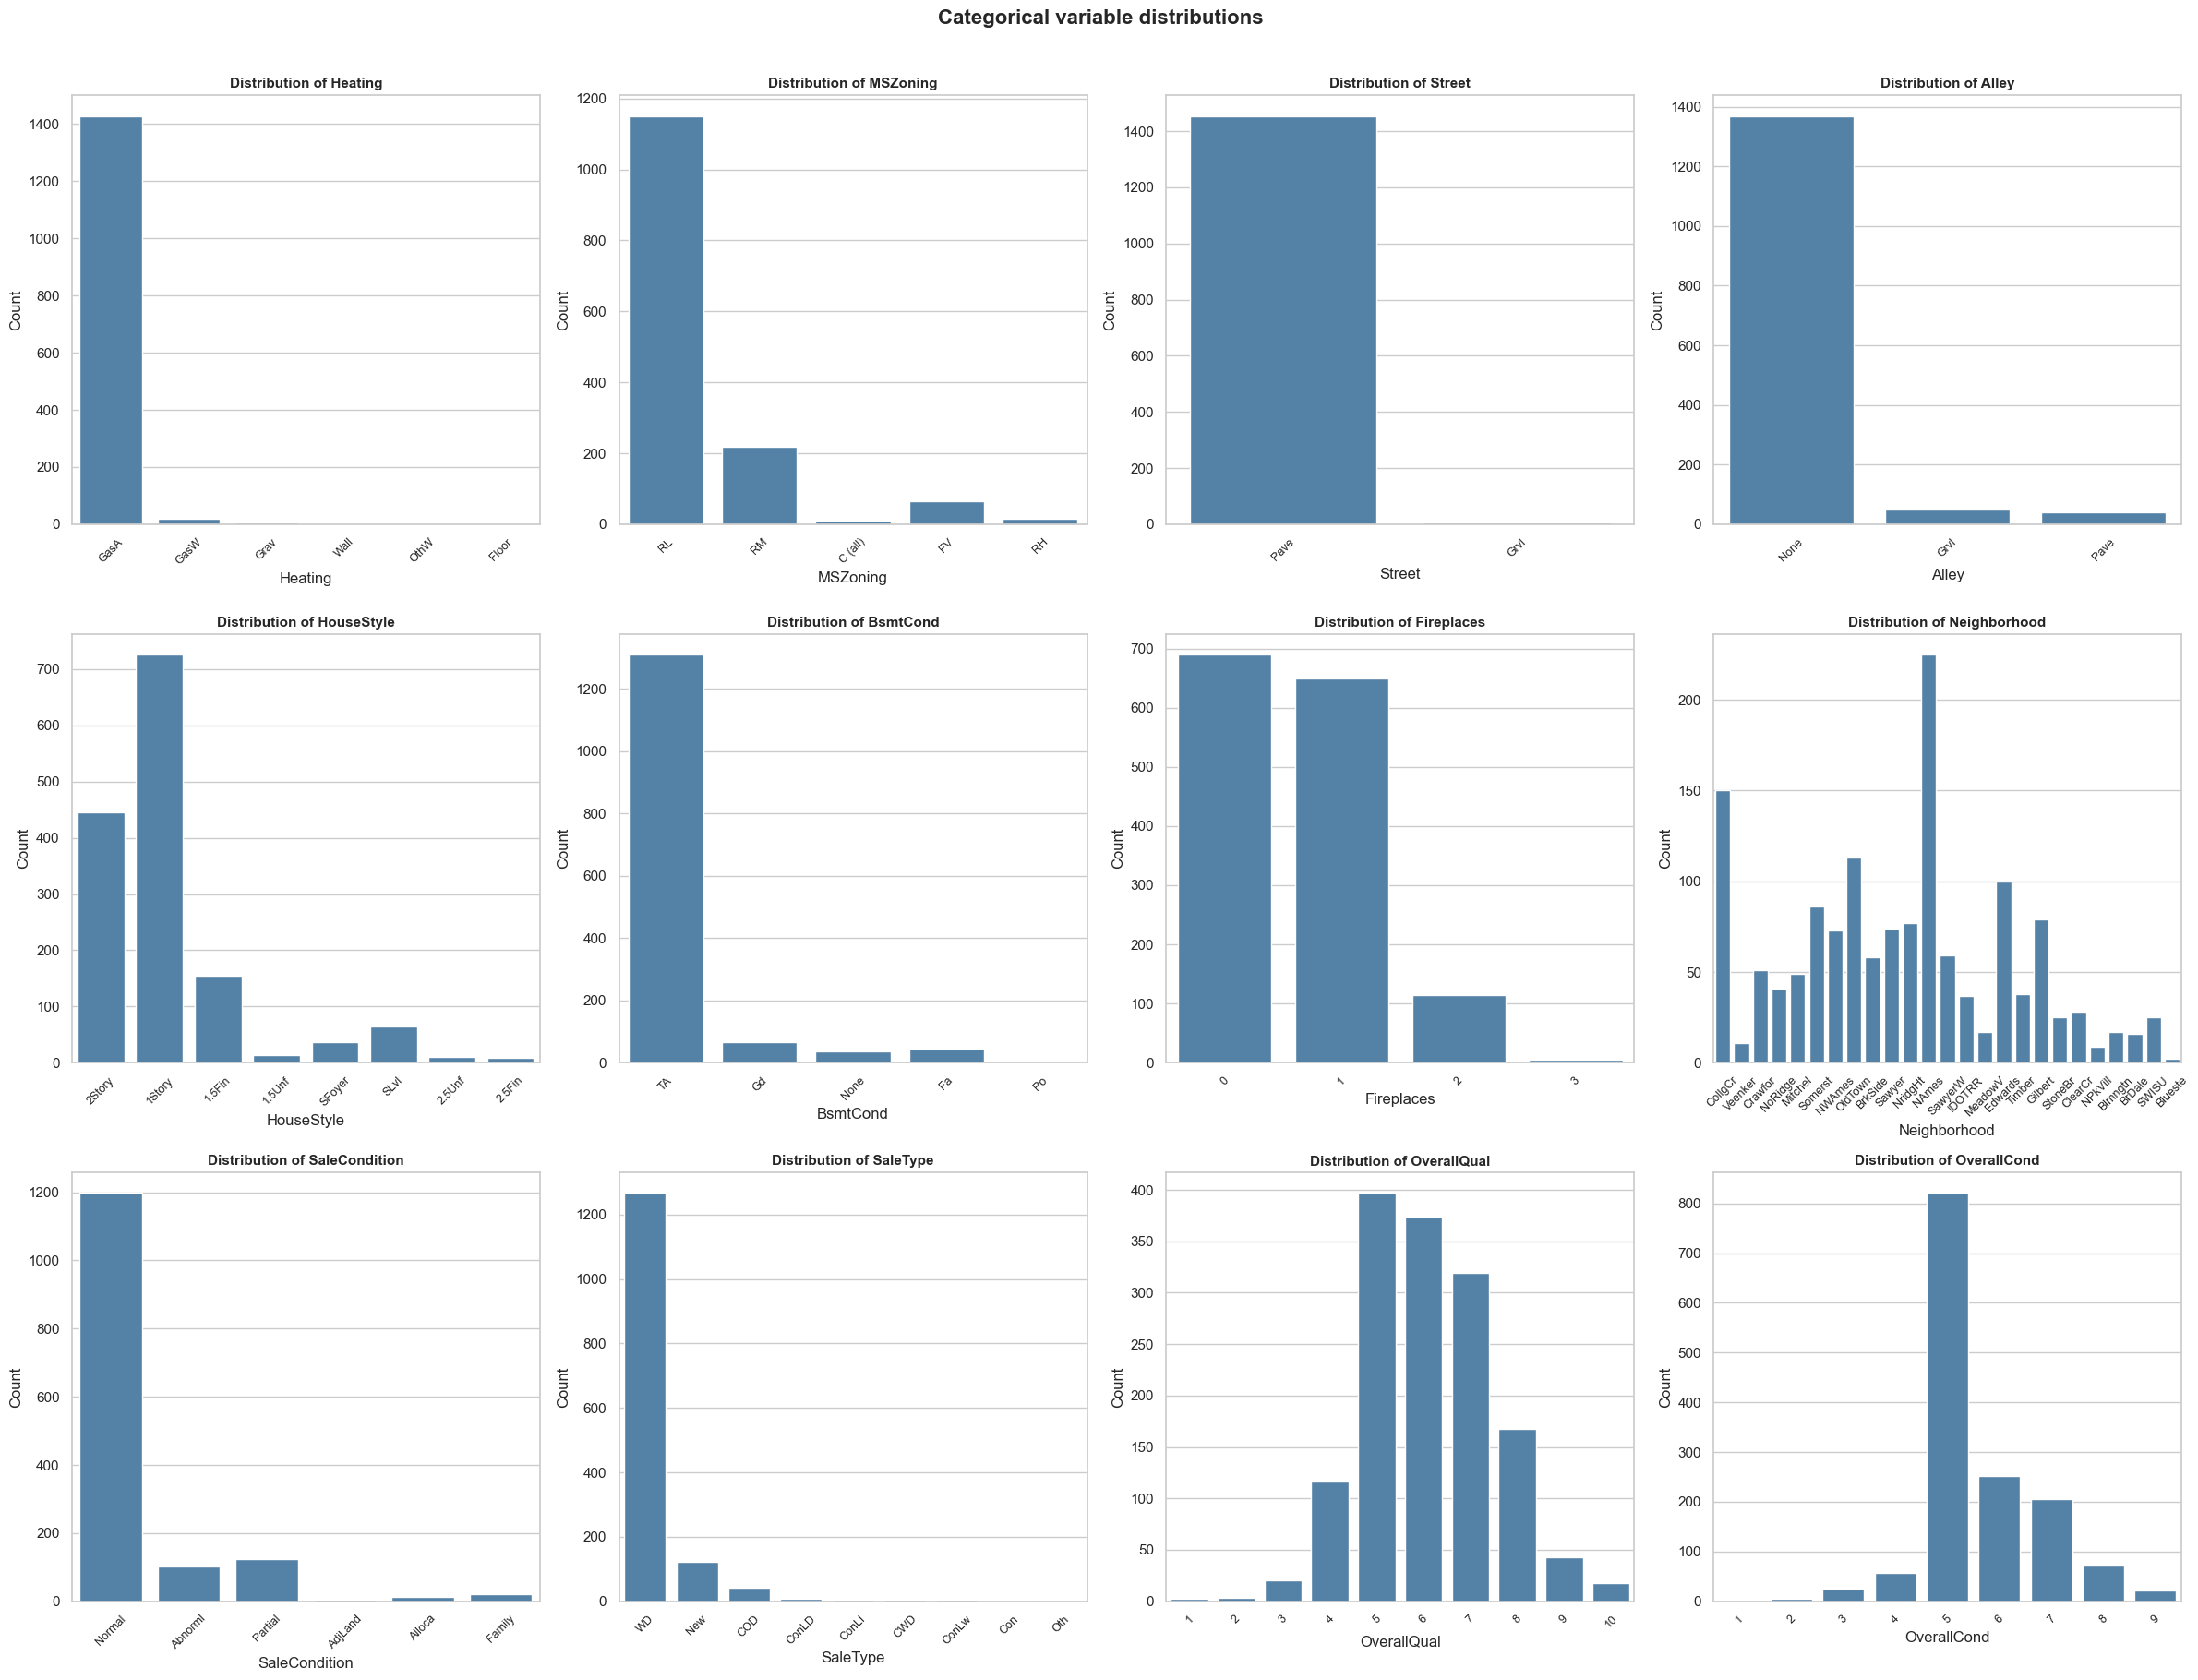

In [176]:
# Create categorical distribution plots with Count on the y axis
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtCond', 'Fireplaces', 'Neighborhood', 'SaleCondition', 'SaleType', 'OverallQual', 'OverallCond']

fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)

for idx in range(len(variables), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical variable distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Etapa 3 – Preparação para Modelagem

Nesta seção serão feitas transformações, seleção de variáveis e preparação para ajuste de modelos. (Espaço reservado para passos de engenharia de features e divisão treino/teste.)